<a href="https://colab.research.google.com/github/vedevpatel/CIFAR-10/blob/main/CIFAR_10_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Summary
The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 5000 images from each class.



## Packages & Imports

In [ ]:
!pip install datasets

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

## Loading the Dataset

In [ ]:
from datasets import load_dataset
dataset = load_dataset("uoft-cs/cifar10")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:85: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

## Data Inspection

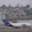

In [ ]:
# Training split
train_data = dataset['train']

# First image & label
first_image = train_data[0]['img']
first_label = train_data[0]['label']

first_image

### Displaying features/classes

In [ ]:
print(train_data.features)

{'img': Image(mode=None, decode=True), 'label': ClassLabel(names=['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])}


The label feature is of ClassLabel type, which has a names attribute to get all class labels.

In [ ]:
class_labels = train_data.features['label'].names
print("Class Labels:", class_labels)

Class Labels: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


So, the classes we are working with are:
airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

### Number of Images per Class

In [ ]:
train_labels = [item['label'] for item in train_data]
label_counts = pd.Series(train_labels).value_counts().sort_index()

label_counts.index = label_counts.index.map(lambda x: class_labels[x])

print("Distribution of images per class (Training Set):")
display(label_counts)

Distribution of images per class (Training Set):


,count
airplane,5000
automobile,5000
bird,5000
cat,5000
deer,5000
dog,5000
frog,5000
horse,5000
ship,5000
truck,5000


### Check for Unclassified Images
Just verifying by checking for any None or out-of-bound label values.

In [ ]:
unclassified_count = sum(1 for item in train_data if item['label'] is None or item['label'] not in range(len(class_labels)))

if unclassified_count == 0:
    print("No unclassified images")
else:
    print(f"{unclassified_count} unclassified images")

No unclassified images


### Image Pixel Dimensions
Checking the size of the images

In [ ]:
print(f"All images are {first_image.size[0]}x{first_image.size[1]} pixels.")

All images are 32x32 pixels.


## Data Visualization
Plotting a few images from the training set to see what they look like.

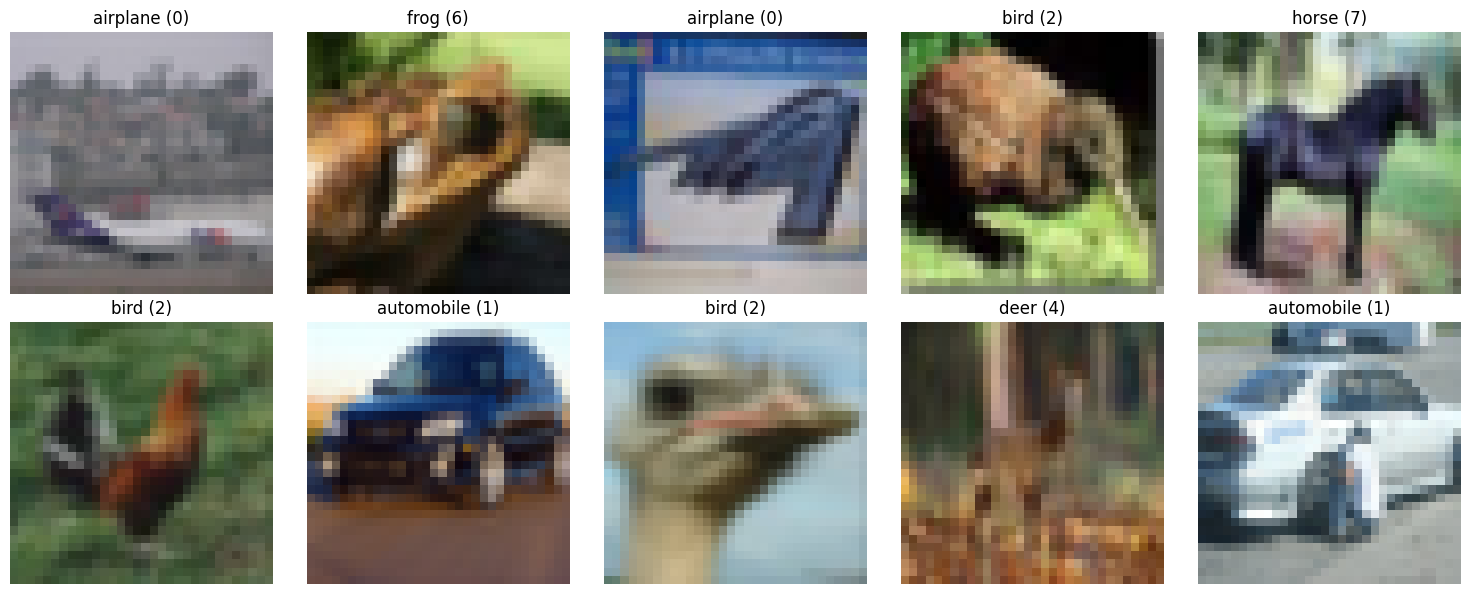

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    img = train_data[i]['img']
    label_idx = train_data[i]['label']
    label_name = class_labels[label_idx]

    axes[i].imshow(img)
    axes[i].set_title(f"{label_name} ({label_idx})")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Data Splitting

Plan: Split off 10% of the training set and allocate it to the validation set. Then, convert PIL images into PyTorch tensors and normalize the pixel values for the training, validation, and test set sequentially. Then, we can augment the training set for better generalization.

In [ ]:
# 90% training 10% validation
split_dataset = train_data.train_test_split(test_size=0.1, seed=42)

train_data = split_dataset['train']
val_data = split_dataset['test']  # train_test_split names the test split 'test' by default

print(f"Training set size: {len(train_data)}")
print(f"Validation set size: {len(val_data)}")


Training set size: 45000
Validation set size: 5000


### Checking the class distribution for the Validation Set

- The natural variation is normal and won't negatively impact the model training.

In [ ]:
val_labels = [item['label'] for item in val_data]
label_counts = pd.Series(val_labels).value_counts().sort_index()

label_counts.index = label_counts.index.map(lambda x: class_labels[x])

print("Distribution of images per class (Validation Set):")
display(label_counts)

Distribution of images per class (Validation Set):


,count
airplane,490
automobile,487
bird,463
cat,447
deer,513
dog,517
frog,526
horse,539
ship,502
truck,516


## Data Preprocessing
- Need to define transformations to convert the PIL images (python objects from the python image library) into PyTorch tensors and normalize the pixel values.

- Images are represented in arrays of pixel values [0-255] for each color channel (RGB). We need to normalize, or transform the pixel values to a specific range. In practice, images are usually normalized to either [0,1] or [-1,1].

- In our case, we'll normalize [-1,1], or center around zero because if all input features are positive, the gradients during backpropagation are either all positive or all negative, which could cause slower convergence in the optimization.


- Also setting up a DataLoader to better iterate through the dataset in batches during training.

### Data Augmentation
We apply data augmentation (like RandomHorizontalFlip and RandomRotation) only to the training set. We do this to artificially expand our dataset and prevent overfitting, as well as forcing the model to learn generalized features instead of memorizing the exact format of the training images.

We do not augment the validation or test sets because we want to evaluate the model on standard and unmodified images that represent real-world input.

In [ ]:
# Base transform for validation and test sets (no augmentation)
val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Train transform w/ aggressive data augmentation
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0) # NEW: Random Erasing
])

# Function to apply train transforms to a batch
def preprocess_train(batch):
    batch['pixel_values'] = [train_transform(img) for img in batch['img']]
    return batch

# Function to apply val/test transforms to a batch
def preprocess_val_test(batch):
    batch['pixel_values'] = [val_test_transform(img) for img in batch['img']]
    return batch

- We randomly shuffle the training data. The reason is, while training, the model learns by looking at a batch of images, predicting, finding the loss, and then updating the weights. If we don't shuffle the data, it's possible for it to be ordered by class. If the model sees multiple batches of a single class, it'll adjust it's weights heavily to recognize that class. Then, when the batch changes the class, it'll have to make the heavy update to account for learning the new class, and that process could make it 'forget' the previous class.

- If we shuffle, we introduce images of different classes randomly to the model, and therefore, keep the weight updates stable.

- It's also important to acknowledge that we do not shuffle the validation and test sets. The reason is, when we run data through those sets, the model isn't learning. It's only making predictions based on it's learned weights. Since the weights aren't being updated, the order in which we present the images doesn't change the final statistics.

- We want determinism while evaluation, which makes it easier to go back and trace specific results for specific runs.


In [ ]:
# Extract the test set from the original dataset
test_data = dataset['test']

# Apply specific transforms to datasets
train_data.set_transform(preprocess_train)
val_data.set_transform(preprocess_val_test)
test_data.set_transform(preprocess_val_test)

# Make the DataLoaders to batch the data
batch_size = 64

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print(f"Train Loader: {len(train_loader)} batches")
print(f"Validation Loader: {len(val_loader)} batches")
print(f"Test Loader: {len(test_loader)} batches")

Train Loader: 704 batches
Validation Loader: 79 batches
Test Loader: 157 batches


# Reasoning on architecture of the CNN model

## First convolutional layer

We know CIFAR-10 has 32x32 pixel images, and they're in color RGB.

The first convolutional layer needs to know how many channels of data it'll be receiving as input.

How convolution layers process images:

Pytorch: nn.Conv2d: A module to apply 2D spatial convolutions over multi-channel data.
- The expected parameters are:
  1. in_channels(int): Number of channels in the input (3 for us), since we're using colored images.

  2. out_channels(int): Number of kernels we want the layer to learn. We will go with a 32->64->128 approach, as we want to go from capturing local nuances to larger parts of the images that require a bit of semantic understanding and be able to store all of that information.
  
  3. kernel_size(int/tuple): The dimensions of the sliding window filter. We will use a 3x3 kernel to make sure we're capturing local detail on the already small 32x32 images.

## After the convolutional layer

After a convolutional layer extracts features, we need to process those features before passing them deeper into the network.

1.  Activation Function (ReLU): We apply a non-linear activation function. Convolutions are linear operations. If we only use linear operations, our network would retain a single linear transformation. ReLU replaces all negative pixel values in the feature map with zero, which brings non-linearity.

2.  Pooling Layer (Max Pooling): After activation, apply a pooling layer to downsample the spatial dimensions (height and width) of the image. A MaxPool2d(2, 2) slides a 2x2 window over the feature map and keeps only the maximum value in that window.
    - It halves the image dimensions (from 32x32 to 16x16), which reduces the num. of parameters & computations for the next layers. It also makes the network more generalized to small shifts in the image.

3. Fully Connected Layers: After the convolutional & pooling layers extract the hierarchical features from the input image and reduce the spatial dimensions, the fully connected layers act as a classifier. Before going into the first fully connected layer, the 3D output (channels, height, width) from the last pooling layer needs to be flattened into a 1D vector. This converts the spatial feature maps into a single long vector of features. The purpose of these layers are to take all the features learned by the previous convolutional layers and learn non-linear combinations of these features.

  - Then, the final fully connected layer has an output size equal to the number of classes in the classification problem, which is 10 in our case. Each output unit corresponds to a class,

In [ ]:
class CIFAR10Model(nn.Module):
    def __init__(self):
        super(CIFAR10Model, self).__init__()

        # Block 1: 64 channels
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.2)

        # Block 2: 128 channels
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout(0.3)

        # Block 3: 256 channels
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.conv6 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.drop3 = nn.Dropout(0.4)

        # Block 4: 512 channels (NEW)
        self.conv7 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn7 = nn.BatchNorm2d(512)
        self.conv8 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn8 = nn.BatchNorm2d(512)
        self.pool4 = nn.MaxPool2d(2, 2)
        self.drop4 = nn.Dropout(0.5)

        # Fully Connected Classifier
        # 4 max pools shrink the 32x32 image to 2x2.
        # 512 channels * 2 * 2 = 2048 features.
        self.fc1 = nn.Linear(512 * 2 * 2, 512)
        self.bn_fc1 = nn.BatchNorm1d(512)
        self.drop_fc = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        # Pass through Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.drop1(self.pool1(x))

        # Pass through Block 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.drop2(self.pool2(x))

        # Pass through Block 3
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.drop3(self.pool3(x))

        # Pass through Block 4
        x = F.relu(self.bn7(self.conv7(x)))
        x = F.relu(self.bn8(self.conv8(x)))
        x = self.drop4(self.pool4(x))

        # Flatten
        x = x.view(-1, 512 * 2 * 2)

        # FC layers
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.drop_fc(x)
        x = self.fc2(x)
        return x

# Instantiate model
model = CIFAR10Model()
print(model)


CIFAR10Model(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.2, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.3, inplace=False)
  (conv5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), p

## Loss Function and Optimizer
Before writing the training loop, define the loss function & the optimizer that updates the model parameters.

- CrossEntropyLoss applies softmax to the outputs and calculates the negative log likelihood.


In [ ]:
epochs = 60

lossFunc = nn.CrossEntropyLoss()

# Switched to SGD with momentum and weight decay (L2 Regularization)
optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=0.9, weight_decay=1e-4)

# Switched to Cosine Annealing Learning Rate Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

## Device Config
Checking if CUDA is available

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model.to(device)

Using device: cuda


CIFAR10Model(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.2, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.3, inplace=False)
  (conv5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), p

## Training Loop

In [ ]:
def custom_collate(batch):
    return {
        'pixel_values': torch.stack([item['pixel_values'] for item in batch]),
        'label': torch.tensor([item['label'] for item in batch])
    }

train_loader = DataLoader(train_loader.dataset, batch_size=train_loader.batch_size, shuffle=True, collate_fn=custom_collate)
val_loader = DataLoader(val_loader.dataset, batch_size=val_loader.batch_size, shuffle=False, collate_fn=custom_collate)

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    # Training
    model.train()
    running_loss = 0.0

    for batch in train_loader:
        # Get inputs and labels from the batch
        inputs = batch['pixel_values'].to(device)
        labels = batch['label'].to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = lossFunc(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval() # evaluation mode
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): # Disable gradient calculation for validation
        for batch in val_loader:
            inputs = batch['pixel_values'].to(device)
            labels = batch['label'].to(device)

            outputs = model(inputs)
            loss = lossFunc(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)

            # Find accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    val_accuracy = 100 * correct / total
    val_accuracies.append(val_accuracy)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Accuracy: {val_accuracy:.2f}% | LR: {current_lr:.6f}")

    # Step the scheduler (Cosine Annealing does not need the val_accuracy passed to it)
    scheduler.step()

print("\nDone")

Epoch 1/60 | Train Loss: 2.1808 | Val Loss: 1.6453 | Val Accuracy: 40.02% | LR: 0.050000
Epoch 2/60 | Train Loss: 1.5619 | Val Loss: 1.3241 | Val Accuracy: 50.64% | LR: 0.049966
Epoch 3/60 | Train Loss: 1.3804 | Val Loss: 1.1417 | Val Accuracy: 60.14% | LR: 0.049863
Epoch 4/60 | Train Loss: 1.2675 | Val Loss: 0.9672 | Val Accuracy: 66.68% | LR: 0.049692
Epoch 5/60 | Train Loss: 1.1571 | Val Loss: 0.8753 | Val Accuracy: 69.52% | LR: 0.049454
Epoch 6/60 | Train Loss: 1.0612 | Val Loss: 0.8507 | Val Accuracy: 69.88% | LR: 0.049148
Epoch 7/60 | Train Loss: 0.9941 | Val Loss: 0.7560 | Val Accuracy: 72.74% | LR: 0.048776
Epoch 8/60 | Train Loss: 0.9444 | Val Loss: 0.7130 | Val Accuracy: 74.92% | LR: 0.048340
Epoch 9/60 | Train Loss: 0.8942 | Val Loss: 0.6616 | Val Accuracy: 77.00% | LR: 0.047839
Epoch 10/60 | Train Loss: 0.8543 | Val Loss: 0.6855 | Val Accuracy: 77.08% | LR: 0.047275
Epoch 11/60 | Train Loss: 0.8204 | Val Loss: 0.5965 | Val Accuracy: 79.54% | LR: 0.046651
Epoch 12/60 | Train

## Training Visualization
Plot the training and validation losses, and validation accuracy.

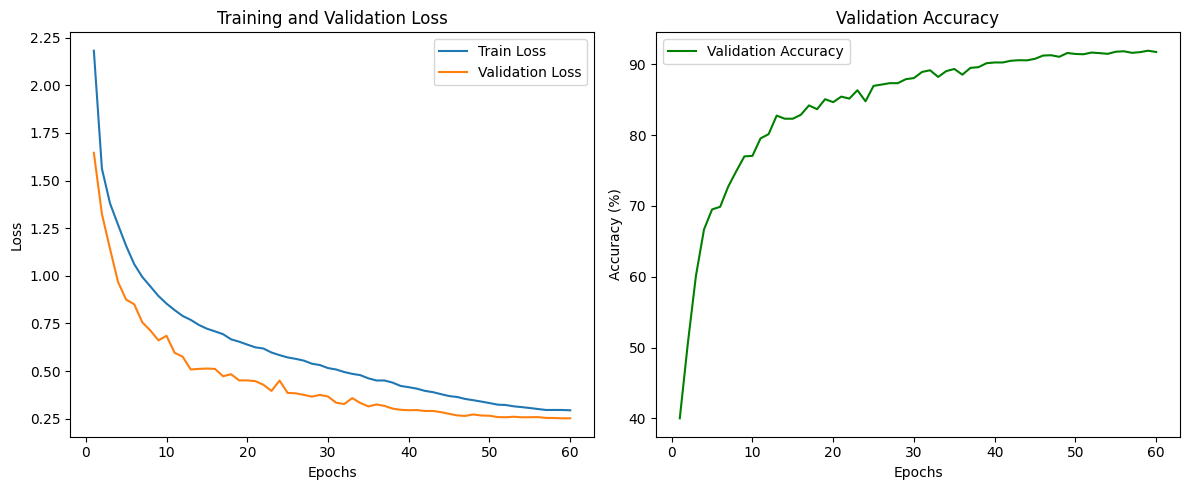

In [ ]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='green')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

## Final Evaluation on Test Set


Final Test Set Results:
Test Loss: 0.2527
Test Accuracy: 91.75%



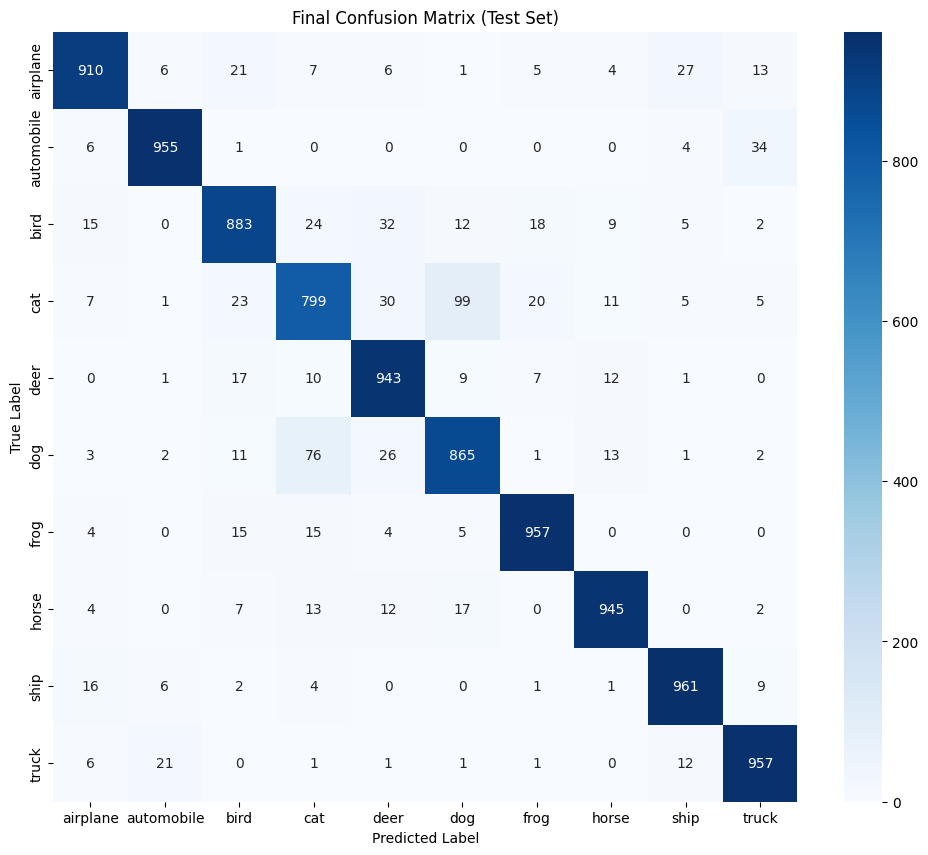

In [ ]:
test_loader = DataLoader(test_loader.dataset, batch_size=test_loader.batch_size, shuffle=False, collate_fn=custom_collate)

# Evaluation mode
model.eval()

running_test_loss = 0.0
correct = 0
total = 0

# To store all predictions and true labels for the confusion matrix
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs = batch['pixel_values'].to(device)
        labels = batch['label'].to(device)

        outputs = model(inputs)
        loss = lossFunc(outputs, labels)
        running_test_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Store predictions and labels
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate final metrics
test_loss = running_test_loss / len(test_loader.dataset)
test_accuracy = 100 * correct / total

print(f"\nFinal Test Set Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%\n")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Final Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## Saving and Loading the Model

In [ ]:
model_save_path = 'cifar10_model.pth'

torch.save(model.state_dict(), model_save_path)
print(f"Model weights saved to {model_save_path}")

'''
# If needed to load the model back in without retraining:
# 1. Instantiate the model architecture
loaded_model = CIFAR10Model()

# 2. Load the saved weights into the model
loaded_model.load_state_dict(torch.load(model_save_path))

# 3. Move it to the correct device (GPU/CPU)
loaded_model.to(device)
loaded_model.eval() # Set to evaluation mode
'''

Model weights saved to cifar10_model.pth


'\n# If needed to load the model back in without retraining:\n# 1. Instantiate the model architecture\nloaded_model = CIFAR10Model()\n\n# 2. Load the saved weights into the model\nloaded_model.load_state_dict(torch.load(model_save_path))\n\n# 3. Move it to the correct device (GPU/CPU)\nloaded_model.to(device)\nloaded_model.eval() # Set to evaluation mode\n'